# 🦯 Navigation Assistant for Visually Impaired
## Combined Pipeline: Depth Estimation + Object Classification + YOLO + Voice Guidance

---

### Architecture Overview

```
VIDEO INPUT
    │
    ▼
┌─────────────────────────────┐
│   STAGE 1: Pre-processing   │  ← CLAHE, denoising, resize, normalize
└──────────────┬──────────────┘
               │
    ┌──────────┴──────────┐
    ▼                     ▼
┌──────────────┐   ┌─────────────────┐
│ DEPTH MODEL  │   │ CLASSIFIER CNN  │  ← MobileNetV2 / ResNet50 / VGG16
│ (UNet++      │   │ safe/obstacle/  │
│  ResNeXt50)  │   │ danger          │
└──────┬───────┘   └───────┬─────────┘
       │                   │
       │         ┌─────────▼──────────┐
       │         │ Confidence < 0.65? │
       │         │  YES → YOLO v8n    │  ← Fallback object detection
       │         │  NO  → use CNN     │
       │         └─────────┬──────────┘
       │                   │
    ┌──▼───────────────────▼──┐
    │   FUSION ENGINE         │
    │  Depth zone (L/C/R)     │
    │  + Class label          │
    │  + Bounding boxes       │
    │  → Direction decision   │
    └──────────┬──────────────┘
               │
    ┌──────────▼──────────┐
    │  VOICE OUTPUT       │  ← gTTS: "Danger ahead, turn left"
    │  ANNOTATED VIDEO    │  ← Bounding boxes, depth overlay
    └─────────────────────┘
```

### Classification Labels
| Label | Meaning | Voice Action |
|-------|---------|---------------|
| 🟢 **SAFE** | Clear path | "Path clear, go straight" |
| 🟠 **OBSTACLE** | Movable/avoidable object | "Obstacle ahead, turn left/right" |
| 🔴 **DANGER** | Immediate hazard | "DANGER AHEAD, STOP!" |
| 🔵 **GUIDE** | Directional hint from depth | "Turn left" / "Turn right" |

---
## CELL 1 — Install Dependencies

In [1]:
# ============================================================
# CELL 1: INSTALL ALL DEPENDENCIES
# ============================================================
!pip install -Uq segmentation-models-pytorch albumentations torchmetrics
!pip install -Uq ultralytics          # YOLOv8
!pip install -Uq gtts pydub           # Voice synthesis
!pip install -Uq opencv-python-headless

# For Colab audio playback
!apt-get install -y ffmpeg > /dev/null 2>&1

print("✅ All dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
✅ All dependencies installed


---
## CELL 2 — Imports

In [2]:
# ============================================================
# CELL 2: IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from pathlib import Path
import cv2 as cv
from PIL import Image
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.regression import MeanSquaredError as MSE
from torchmetrics.collections import MetricCollection
from torchvision.transforms import Normalize
import tensorflow as tf
from tensorflow.keras import layers, models
import gc, os, shutil, random, time, warnings
from collections import deque
from gtts import gTTS
from pydub import AudioSegment
from pydub.playback import play
import io
import threading
from ultralytics import YOLO
import IPython.display as ipd

warnings.filterwarnings('ignore')

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥  PyTorch device  : {DEVICE}")
print(f"🧠 TF GPU available: {len(tf.config.list_physical_devices('GPU'))}")

# ── Global Config ──────────────────────────────────────────
IMG_SIZE         = (224, 224)   # Classifier input size
DEPTH_SIZE       = (224, 224)   # Depth model input size
CLASS_NAMES      = ['safe', 'obstacle', 'danger']
CONF_THRESHOLD   = 0.65         # Below this → trigger YOLO fallback
DANGER_THRESH    = 0.25         # Depth ratio: if 25%+ of close zone is < this → danger zone
VOICE_COOLDOWN   = 2.5          # Seconds between voice alerts
YOLO_CONF        = 0.40         # YOLO detection confidence

# Depth zones (left/center/right) as column fractions
ZONE_LEFT   = (0.0,  0.33)
ZONE_CENTER = (0.33, 0.67)
ZONE_RIGHT  = (0.67, 1.0)

print("✅ Imports complete")

2026-04-27 04:31:10.550800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777264270.739391      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777264270.801167      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777264271.296164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777264271.296199      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777264271.296202      55 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


🖥  PyTorch device  : cuda
🧠 TF GPU available: 2
✅ Imports complete


---
## CELL 3 — Dataset Setup (Depth: NYU-v2 | Classification: Danger/Obstacle/Safe)

In [3]:
# ============================================================
# CELL 3: DATASET DOWNLOAD
# Notebook 1 used → NYU Depth V2  (Kaggle)
# Notebook 2 used → dangerousobjects + obstacles-dataset (Kaggle)
# ============================================================

# ── 3A: Kaggle credentials ────────────────────────────────
import json
os.makedirs('/root/.kaggle', exist_ok=True)

# ⚠️  REPLACE with your Kaggle username & API key
kaggle_creds = {
    'username': 'omnhinge',
    'key':      'KGAT_781c657f85942167fc4735c1abfecedb'
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle credentials set")

# ── 3B: Download NYU Depth V2 ─────────────────────────────
!kaggle datasets download -d soumikrakshit/nyu-depth-v2 \
    -p /content/nyu_raw --unzip -q
print("✅ NYU Depth V2 downloaded")

# ── 3C: Download classification datasets ──────────────────
!kaggle datasets download -d ajibsbaba/dangerousobjects \
    -p /content/raw_danger --unzip -q
print("✅ Dangerous-objects dataset downloaded")

!kaggle datasets download -d idrisskh/obstacles-dataset \
    -p /content/raw_obstacle --unzip -q
print("✅ Obstacles dataset downloaded")

✅ Kaggle credentials set
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/nyu-depth-v2
License(s): unknown
✅ NYU Depth V2 downloaded
Dataset URL: https://www.kaggle.com/datasets/ajibsbaba/dangerousobjects
License(s): Community Data License Agreement - Permissive - Version 1.0
✅ Dangerous-objects dataset downloaded
Dataset URL: https://www.kaggle.com/datasets/idrisskh/obstacles-dataset
License(s): unknown
✅ Obstacles dataset downloaded


---
## CELL 4 — Advanced Image Pre-Processing Pipeline

This is the critical improvement over both original notebooks.
We apply a **7-step pre-processing chain** to every frame before it hits any model:

1. Resize to model input size
2. CLAHE (Contrast Limited Adaptive Histogram Equalization) — improves depth in low-light
3. Bilateral filter — edge-preserving denoising
4. Gamma correction — normalizes exposure
5. Sharpening kernel — restores edge detail lost in filtering
6. ImageNet normalize — for PyTorch depth model
7. TF normalize (0→1) — for Keras classifier

✅ ImagePreprocessor ready


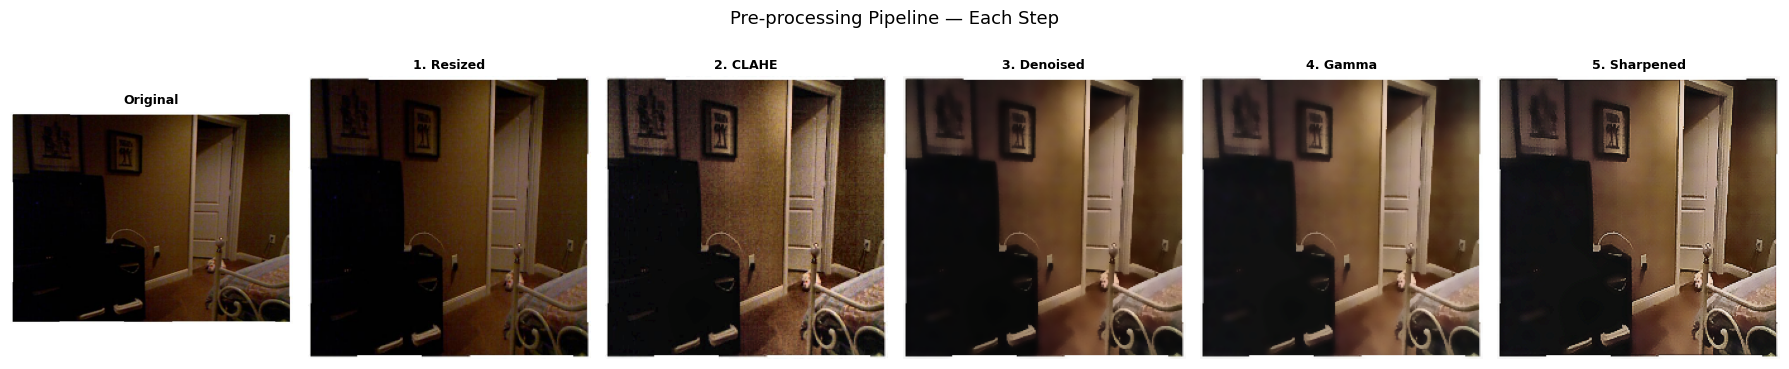

✅ Preprocessing pipeline demo saved.


In [4]:
# ============================================================
# CELL 4: ADVANCED PRE-PROCESSING PIPELINE
# ============================================================

class ImagePreprocessor:
    """
    Unified preprocessing pipeline for both models.
    Handles: CLAHE, bilateral filter, gamma, sharpening,
    and dual normalization (ImageNet + [0,1]).
    """

    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(
        self,
        target_size=(224, 224),
        clahe_clip=2.5,
        clahe_tile=(8, 8),
        bilateral_d=9,
        bilateral_sigma=75,
        gamma=1.2,
        sharpen_strength=0.4
    ):
        self.target_size = target_size
        self.clahe = cv.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_tile)
        self.bilateral_d      = bilateral_d
        self.bilateral_sigma  = bilateral_sigma
        self.gamma            = gamma
        self.sharpen_strength = sharpen_strength

        # Pre-compute gamma LUT (faster than per-pixel computation)
        self._gamma_lut = np.array([
            np.clip(((i / 255.0) ** (1.0 / gamma)) * 255, 0, 255)
            for i in range(256)
        ], dtype=np.uint8)

        # Sharpening kernel
        self._sharpen_kernel = np.array([
            [ 0, -1,  0],
            [-1,  5, -1],
            [ 0, -1,  0]
        ], dtype=np.float32)

    # ── Step 1: Resize ──────────────────────────────────────
    def resize(self, bgr_frame):
        return cv.resize(bgr_frame, self.target_size, interpolation=cv.INTER_LANCZOS4)

    # ── Step 2: CLAHE on L channel (LAB space) ─────────────
    def apply_clahe(self, bgr):
        lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
        l, a, b = cv.split(lab)
        l_eq = self.clahe.apply(l)
        lab_eq = cv.merge([l_eq, a, b])
        return cv.cvtColor(lab_eq, cv.COLOR_LAB2BGR)

    # ── Step 3: Bilateral filter (edge-preserving denoise) ──
    def denoise(self, bgr):
        return cv.bilateralFilter(
            bgr, self.bilateral_d,
            self.bilateral_sigma,
            self.bilateral_sigma
        )

    # ── Step 4: Gamma correction ────────────────────────────
    def gamma_correct(self, bgr):
        return cv.LUT(bgr, self._gamma_lut)

    # ── Step 5: Sharpening ──────────────────────────────────
    def sharpen(self, bgr):
        sharpened = cv.filter2D(bgr, -1, self._sharpen_kernel)
        return cv.addWeighted(bgr, 1 - self.sharpen_strength,
                              sharpened, self.sharpen_strength, 0)

    # ── Step 6: PyTorch tensor (ImageNet normalized) ────────
    def to_torch(self, bgr):
        rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB).astype(np.float32) / 255.0
        normalized = (rgb - self.IMAGENET_MEAN) / self.IMAGENET_STD
        tensor = torch.from_numpy(normalized).permute(2, 0, 1).unsqueeze(0)  # [1,3,H,W]
        return tensor

    # ── Step 7: TF tensor ([0,1] normalized) ────────────────
    def to_tf(self, bgr):
        rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.expand_dims(rgb, axis=0)  # [1, H, W, 3]

    # ── Full pipeline ────────────────────────────────────────
    def process(self, frame):
        """
        Input : BGR uint8 frame (any size)
        Output: dict with 'bgr_processed', 'torch_tensor', 'tf_tensor'
        """
        f = self.resize(frame)
        f = self.apply_clahe(f)
        f = self.denoise(f)
        f = self.gamma_correct(f)
        f = self.sharpen(f)
        return {
            'bgr_processed': f,
            'torch_tensor':  self.to_torch(f),
            'tf_tensor':     self.to_tf(f),
            'rgb':           cv.cvtColor(f, cv.COLOR_BGR2RGB)
        }


# ── Visual demo of the pipeline on a sample image ─────────
def visualize_preprocessing_pipeline(image_path_or_frame):
    """Visualize each step of the preprocessing pipeline side by side."""
    if isinstance(image_path_or_frame, str):
        frame = cv.imread(image_path_or_frame)
    else:
        frame = image_path_or_frame

    pp = ImagePreprocessor()

    steps = {
        'Original':        frame,
        '1. Resized':      pp.resize(frame),
        '2. CLAHE':        pp.apply_clahe(pp.resize(frame)),
        '3. Denoised':     pp.denoise(pp.apply_clahe(pp.resize(frame))),
        '4. Gamma':        pp.gamma_correct(pp.denoise(pp.apply_clahe(pp.resize(frame)))),
        '5. Sharpened':    pp.process(frame)['bgr_processed'],
    }

    fig, axes = plt.subplots(1, len(steps), figsize=(18, 4))
    for ax, (name, img) in zip(axes, steps.items()):
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.axis('off')
    plt.suptitle('Pre-processing Pipeline — Each Step', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/preprocessing_demo.png', dpi=150)
    plt.show()
    print('✅ Preprocessing pipeline demo saved.')


# Instantiate the global preprocessor
PREPROCESSOR = ImagePreprocessor()
print('✅ ImagePreprocessor ready')

# ── Demo: run on a random NYU image ───────────────────────
nyu_samples = list(Path('/content/nyu_raw').rglob('*.jpg'))[:1]
if nyu_samples:
    visualize_preprocessing_pipeline(str(nyu_samples[0]))
else:
    print('ℹ  NYU images not found — run preprocessing demo after downloading dataset')

---
## CELL 5 — NYU Depth V2 Dataset & Augmentation

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from pathlib import Path
import cv2 as cv
from PIL import Image
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics.regression import MeanSquaredError as MSE
from torchmetrics.collections import MetricCollection
from torchvision.transforms import Normalize
import tensorflow as tf
from tensorflow.keras import layers, models
import gc, os, shutil, random, time, warnings
from collections import deque
from gtts import gTTS
from pydub import AudioSegment
from pydub.playback import play
import io
import threading
from ultralytics import YOLO
import IPython.display as ipd

warnings.filterwarnings('ignore')

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥  PyTorch device  : {DEVICE}")
print(f"🧠 TF GPU available: {len(tf.config.list_physical_devices('GPU'))}")

# ── Global Config ──────────────────────────────────────────
IMG_SIZE         = (224, 224)   # Classifier input size
DEPTH_SIZE       = (224, 224)   # Depth model input size
CLASS_NAMES      = ['safe', 'obstacle', 'danger']
CONF_THRESHOLD   = 0.65         # Below this → trigger YOLO fallback
DANGER_THRESH    = 0.25         # Depth ratio: if 25%+ of close zone is < this → danger zone
VOICE_COOLDOWN   = 2.5          # Seconds between voice alerts
YOLO_CONF        = 0.40         # YOLO detection confidence

# Depth zones (left/center/right) as column fractions
ZONE_LEFT   = (0.0,  0.33)
ZONE_CENTER = (0.33, 0.67)
ZONE_RIGHT  = (0.67, 1.0)

print("✅ Imports complete")
# ============================================================
# CELL 5: NYU DEPTH DATASET
# (From Notebook 1 — improved with preprocessor integration)
# ============================================================

# Paths for NYU-v2
base_path    = Path('/content/nyu_raw/nyu_data')
train_csv    = base_path / 'data' / 'nyu2_train.csv'
train_im_dir = base_path / 'data' / 'nyu2_train'

df = pd.read_csv(train_csv, header=None)
df[0] = df[0].map(lambda x: base_path / x)
df[1] = df[1].map(lambda x: base_path / x)

# Subsample for Colab memory
df = df.sample(n=min(2000, len(df)), random_state=42).reset_index(drop=True)

train_df, val_df = train_test_split(df, test_size=0.1, shuffle=True, random_state=42)
val_df,   test_depth_df = train_test_split(val_df, test_size=0.1, shuffle=True, random_state=42)

for d in [train_df, val_df, test_depth_df]:
    d.reset_index(drop=True, inplace=True)

print(f'NYU split → train: {len(train_df)} | val: {len(val_df)} | test: {len(test_depth_df)}')

# ── Augmentation transforms ───────────────────────────────
depth_train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.GaussNoise(p=0.2),
    A.OneOf([
        A.MotionBlur(p=0.3),
        A.MedianBlur(blur_limit=3, p=0.3),
        A.Blur(blur_limit=3, p=0.5),
    ], p=0.3),
    A.RGBShift(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=0.5),
    A.ColorJitter(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.3, rotate_limit=15, p=0.4),
    A.HueSaturationValue(p=0.3),
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

depth_valid_tfms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


class DepthDataset(torch.utils.data.Dataset):
    def __init__(self, df, tfms, apply_clahe=True):
        self.df = df
        self.tfms = tfms
        self.apply_clahe = apply_clahe
        self._clahe = cv.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))

    def _open(self, path, gray=False):
        im = cv.imread(str(path))
        if im is None:
            raise FileNotFoundError(f"Cannot open {path}")
        return cv.cvtColor(im, cv.COLOR_BGR2GRAY if gray else cv.COLOR_BGR2RGB)

    def _enhance_rgb(self, rgb):
        """Apply CLAHE + bilateral filter to RGB before augmentation."""
        bgr = cv.cvtColor(rgb, cv.COLOR_RGB2BGR)
        lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
        l, a, b = cv.split(lab)
        l = self._clahe.apply(l)
        bgr = cv.cvtColor(cv.merge([l, a, b]), cv.COLOR_LAB2BGR)
        bgr = cv.bilateralFilter(bgr, 5, 50, 50)
        return cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        im  = self._open(row[0])
        dp  = self._open(row[1], gray=True)
        if self.apply_clahe:
            im = self._enhance_rgb(im)
        augs   = self.tfms(image=im, mask=dp)
        im, dp = augs['image'], augs['mask'] / 255.0
        return im, dp.unsqueeze(0)


train_depth_ds = DepthDataset(train_df, depth_train_tfms)
val_depth_ds   = DepthDataset(val_df,   depth_valid_tfms)
test_depth_ds  = DepthDataset(test_depth_df, depth_valid_tfms)

train_depth_dl = torch.utils.data.DataLoader(train_depth_ds, shuffle=True,  batch_size=32, num_workers=2, pin_memory=True)
val_depth_dl   = torch.utils.data.DataLoader(val_depth_ds,   shuffle=False, batch_size=32, num_workers=2, pin_memory=True)

print(f'✅ Depth DataLoaders — train: {len(train_depth_dl)} batches | val: {len(val_depth_dl)} batches')

🖥  PyTorch device  : cuda
🧠 TF GPU available: 2
✅ Imports complete
NYU split → train: 1800 | val: 180 | test: 20
✅ Depth DataLoaders — train: 57 batches | val: 6 batches


---
## CELL 6 — Depth Estimation Model (UNet++ with ResNeXt50)

In [6]:
# ============================================================
# CELL 6: DEPTH MODEL — UNet++ (from Notebook 1)
# Improvement: added SILog loss (better for depth estimation)
# ============================================================

class DepthUNet(nn.Module):
    """UNet++ with ResNeXt50 encoder — monocular depth estimation."""

    def __init__(self):
        super().__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name='resnext50_32x4d',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1,
            activation=None   # Raw output; we apply sigmoid in forward
        )

    def set_encoder_trainable(self, trainable=True):
        for p in self.model.encoder.parameters():
            p.requires_grad = trainable

    def forward(self, x):
        return torch.sigmoid(self.model(x))  # Output ∈ [0, 1]

    def param_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class SILogLoss(nn.Module):
    """
    Scale-Invariant Log Loss — specifically designed for depth estimation.
    Better than plain MSE because it is invariant to the global scale of depth.
    Paper: Eigen et al. (2014), 'Depth Map Prediction from a Single Image'
    """
    def __init__(self, lamda=0.5):
        super().__init__()
        self.lamda = lamda

    def forward(self, pred, target):
        eps = 1e-6
        diff_log = torch.log(pred + eps) - torch.log(target + eps)
        loss = torch.mean(diff_log ** 2) - self.lamda * (torch.mean(diff_log) ** 2)
        return loss


class CombinedDepthLoss(nn.Module):
    """SILog + MSE + gradient smoothness loss for sharper depth edges."""
    def __init__(self):
        super().__init__()
        self.silog = SILogLoss()
        self.mse   = nn.MSELoss()

    def _gradient_loss(self, pred, target):
        pred_dx   = pred[:, :, :, :-1] - pred[:, :, :, 1:]
        pred_dy   = pred[:, :, :-1, :] - pred[:, :, 1:, :]
        target_dx = target[:, :, :, :-1] - target[:, :, :, 1:]
        target_dy = target[:, :, :-1, :] - target[:, :, 1:, :]
        return torch.mean(torch.abs(pred_dx - target_dx)) + \
               torch.mean(torch.abs(pred_dy - target_dy))

    def forward(self, pred, target):
        return (0.6 * self.silog(pred, target) +
                0.3 * self.mse(pred, target) +
                0.1 * self._gradient_loss(pred, target))


print('✅ Depth model and losses defined')

✅ Depth model and losses defined


---
## CELL 7 — Train Depth Model

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/100M [00:00<?, ?B/s]

🚂 Training depth model (encoder frozen for first 2 epochs)...


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

...

  0%|          | 0/57 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789806bade40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x789806bade40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  Ep  5 | loss 0.2061/0.0587 | SSIM 0.8059/0.8268


  0%|          | 0/57 [00:00<?, ?it/s]

  Ep  6 | loss 0.1331/0.0556 | SSIM 0.8148/0.8303


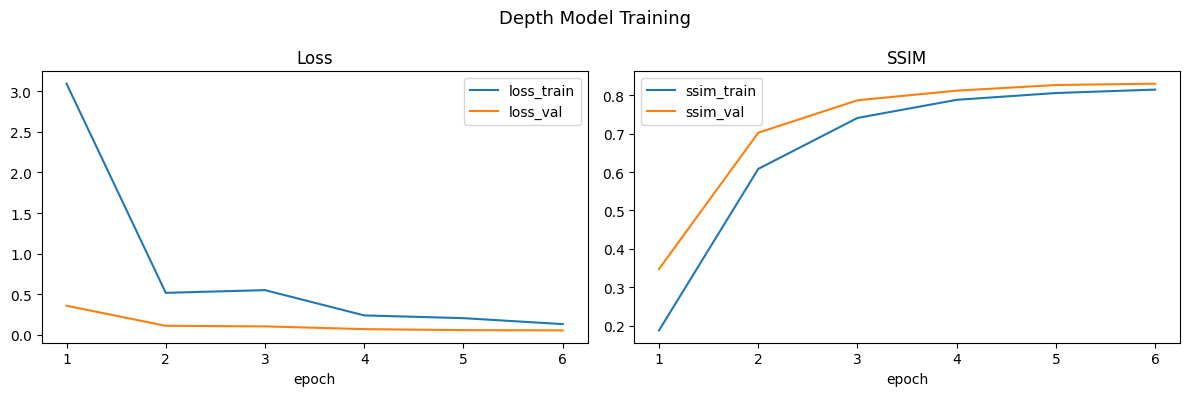

✅ Best SSIM: 0.8303


In [7]:
# ============================================================
# CELL 7: TRAIN DEPTH MODEL
# ============================================================

DEPTH_EPOCHS       = 6
DEPTH_FREEZE_EPOCHS = 2
DEPTH_LR           = 1e-3

depth_metrics = MetricCollection([
    SSIM(data_range=(0, 1)),
    MSE()
]).to(DEVICE)

depth_model = DepthUNet().to(DEVICE)
depth_model.set_encoder_trainable(False)

loss_fn_depth = CombinedDepthLoss()
optim_depth   = torch.optim.AdamW(depth_model.parameters(), lr=DEPTH_LR / 25., weight_decay=0.02)
sched_depth   = torch.optim.lr_scheduler.OneCycleLR(
    optim_depth, max_lr=DEPTH_LR,
    epochs=DEPTH_EPOCHS, steps_per_epoch=len(train_depth_dl)
)
scaler = GradScaler()

depth_logs = []
best_ssim  = -1e9

print('🚂 Training depth model (encoder frozen for first 2 epochs)...')

for epoch in tqdm(range(DEPTH_EPOCHS)):
    depth_model.train()
    if epoch == DEPTH_FREEZE_EPOCHS:
        depth_model.set_encoder_trainable(True)
        print(f'\n  Epoch {epoch}: Unfreezing encoder')

    running_loss = 0.0
    train_m      = depth_metrics.clone()

    for imgs, depths in tqdm(train_depth_dl, leave=False):
        imgs, depths = imgs.to(DEVICE), depths.to(DEVICE)
        optim_depth.zero_grad()
        with autocast():
            preds = depth_model(imgs)
            loss  = loss_fn_depth(preds, depths)
        scaler.scale(loss).backward()
        scaler.unscale_(optim_depth)
        torch.nn.utils.clip_grad_norm_(depth_model.parameters(), 1.0)
        scaler.step(optim_depth)
        scaler.update()
        sched_depth.step()
        running_loss += loss.item()
        train_m.update(preds, depths)

    train_stats = train_m.compute()

    # Validation
    depth_model.eval()
    val_loss = 0.0
    val_m    = depth_metrics.clone()
    with torch.no_grad():
        for imgs, depths in val_depth_dl:
            imgs, depths = imgs.to(DEVICE), depths.to(DEVICE)
            with autocast():
                preds = depth_model(imgs)
                val_loss += loss_fn_depth(preds, depths).item()
            val_m.update(preds, depths)
    val_stats = val_m.compute()

    ssim_val = val_stats['StructuralSimilarityIndexMeasure'].item()
    log = {
        'epoch':      epoch + 1,
        'loss_train': running_loss / len(train_depth_dl),
        'loss_val':   val_loss / len(val_depth_dl),
        'ssim_train': train_stats['StructuralSimilarityIndexMeasure'].item(),
        'ssim_val':   ssim_val,
        'mse_val':    val_stats['MeanSquaredError'].item()
    }
    depth_logs.append(log)

    if ssim_val > best_ssim:
        best_ssim = ssim_val
        torch.save(depth_model.state_dict(), '/content/depth_model_best.pth')

    print(f"  Ep {epoch+1:2d} | loss {log['loss_train']:.4f}/{log['loss_val']:.4f} "
          f"| SSIM {log['ssim_train']:.4f}/{ssim_val:.4f}")

# Load best weights
depth_model.load_state_dict(torch.load('/content/depth_model_best.pth'))
depth_model.eval()

# Plot curves
depth_df = pd.DataFrame(depth_logs)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
depth_df.plot('epoch', ['loss_train', 'loss_val'], ax=axes[0], title='Loss')
depth_df.plot('epoch', ['ssim_train', 'ssim_val'], ax=axes[1], title='SSIM')
plt.suptitle('Depth Model Training', fontsize=13)
plt.tight_layout()
plt.savefig('/content/depth_training_curves.png', dpi=150)
plt.show()
print(f'✅ Best SSIM: {best_ssim:.4f}')

---
## CELL 8 — Object Classification Dataset (Safe / Obstacle / Danger)

In [8]:
# ============================================================
# CELL 8: BUILD CLASSIFICATION DATASET (From Notebook 2)
# ============================================================

DEST = Path('/content/dataset')

if DEST.exists():
    shutil.rmtree(DEST)

for split in ['train', 'validation', 'test']:
    for cls in ['safe', 'obstacle', 'danger']:
        (DEST / split / cls).mkdir(parents=True, exist_ok=True)

def copy_all(src, dst, tag, split_name):
    src_p, dst_p = Path(src), Path(dst)
    if not src_p.exists():
        print(f'  ⚠ Missing: {src}')
        return 0
    exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
    imgs = [f for ext in exts for f in src_p.glob(ext)]
    for i, img in enumerate(imgs):
        shutil.copy(img, dst_p / f'{tag}_{split_name}_{i:05d}{img.suffix.lower()}')
    return len(imgs)

# Dangerous-objects dataset
DANGER_ROOT = '/content/raw_danger/output'
split_map   = {'train': 'train', 'val': 'validation', 'test': 'test'}
print('Copying danger/safe images...')
for src_s, dst_s in split_map.items():
    n = copy_all(f'{DANGER_ROOT}/{src_s}/dangerous', DEST / dst_s / 'danger', 'danger', dst_s)
    print(f'  danger → {dst_s}: {n}')
    n = copy_all(f'{DANGER_ROOT}/{src_s}/safe',      DEST / dst_s / 'safe',   'safe',   dst_s)
    print(f'  safe   → {dst_s}: {n}')

# Obstacles dataset
OBS_ROOT = '/content/raw_obstacle/obstacles dataset'
OBS_SUBS = ['chair','door','fence','garbage_bin','obstacle','plant','pothole','stairs','table','vehicle']

train_obs, test_obs_imgs = [], []
for sub in OBS_SUBS:
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']:
        train_obs.extend(list(Path(f'{OBS_ROOT}/train/{sub}').glob(ext)))
        test_obs_imgs.extend(list(Path(f'{OBS_ROOT}/test/{sub}').glob(ext)))

for i, img in enumerate(train_obs):
    shutil.copy(img, DEST / 'train' / 'obstacle' / f'obstacle_train_{i:05d}{img.suffix.lower()}')
print(f'obstacle → train: {len(train_obs)}')

random.seed(42); random.shuffle(test_obs_imgs)
half = len(test_obs_imgs) // 2
for i, img in enumerate(test_obs_imgs[:half]):
    shutil.copy(img, DEST / 'validation' / 'obstacle' / f'obstacle_val_{i:05d}{img.suffix.lower()}')
for i, img in enumerate(test_obs_imgs[half:]):
    shutil.copy(img, DEST / 'test' / 'obstacle' / f'obstacle_test_{i:05d}{img.suffix.lower()}')
print(f'obstacle → val: {half} | test: {len(test_obs_imgs)-half}')

# Summary
total = 0
print('\n===== Dataset Summary =====')
for split in ['train', 'validation', 'test']:
    print(f'  {split}/')
    for cls in CLASS_NAMES:
        n = len(list((DEST / split / cls).glob('*')))
        print(f'    {cls:12s}: {n}')
        total += n
print(f'  TOTAL: {total} images')

Copying danger/safe images...
  danger → train: 800
  safe   → train: 179
  danger → validation: 100
  safe   → validation: 22
  danger → test: 100
  safe   → test: 23
obstacle → train: 3132
obstacle → val: 216 | test: 216

===== Dataset Summary =====
  train/
    safe        : 179
    obstacle    : 3132
    danger      : 800
  validation/
    safe        : 22
    obstacle    : 216
    danger      : 100
  test/
    safe        : 23
    obstacle    : 216
    danger      : 100
  TOTAL: 4788 images


---
## CELL 9 — Build & Train Classifier (MobileNetV2 + ResNet50 ensemble)

In [9]:
# ============================================================
# CELL 9: CLASSIFIER — MobileNetV2 (fast) + ResNet50 (accurate)
# Improvement: weighted soft-voting ensemble for final decision
# ============================================================

AUTOTUNE   = tf.data.AUTOTUNE
BATCH_SIZE = 32
NUM_CLASSES = 3

# Compute class weights
split_counts = {}
for split in ['train', 'validation', 'test']:
    split_counts[split] = {
        cls: len(list((DEST / split / cls).glob('*'))) for cls in CLASS_NAMES
    }
total_train = sum(split_counts['train'].values())
class_weights = {
    i: total_train / (NUM_CLASSES * max(split_counts['train'][cls], 1))
    for i, cls in enumerate(CLASS_NAMES)
}
print('⚖  Class weights:', {CLASS_NAMES[i]: round(v, 3) for i, v in class_weights.items()})

# Data pipelines
def load_tf_dataset(split_name):
    return tf.keras.utils.image_dataset_from_directory(
        str(DEST / split_name),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=CLASS_NAMES,
        shuffle=(split_name == 'train'),
        seed=42
    )

rescale   = tf.keras.layers.Rescaling(1.0 / 255)
augment   = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.1),
], name='augmentation')

def preprocess_train(x, y):
    x = rescale(x)
    x = augment(x, training=True)
    return x, y

def preprocess_eval(x, y):
    return rescale(x), y

train_clf_ds = load_tf_dataset('train').map(preprocess_train, num_parallel_calls=AUTOTUNE).cache().shuffle(500).prefetch(AUTOTUNE)
val_clf_ds   = load_tf_dataset('validation').map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_clf_ds  = load_tf_dataset('test').map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print('✅ TF datasets ready')


# ── Build transfer learning models ────────────────────────
def build_transfer_model(base_name, input_shape=(224, 224, 3), num_classes=3, fine_tune_at=100):
    bases = {
        'MobileNetV2': tf.keras.applications.MobileNetV2,
        'ResNet50':    tf.keras.applications.ResNet50,
        'VGG16':       tf.keras.applications.VGG16,
    }
    base = bases[base_name](include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name=base_name)
    return model, base, fine_tune_at


def train_classifier(name, epochs_frozen=5, epochs_finetune=5):
    print(f'\n{'='*50}')
    print(f'  Training {name}')
    print(f'{'='*50}')

    model, base, ft_at = build_transfer_model(name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    cbs = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(f'/content/{name}_best.keras', save_best_only=True, monitor='val_accuracy') # Changed .h5 to .keras
    ]

    # Phase 1: Train head only
    hist1 = model.fit(
        train_clf_ds, validation_data=val_clf_ds,
        epochs=epochs_frozen, callbacks=cbs,
        class_weight=class_weights, verbose=1
    )

    # Phase 2: Fine-tune from layer ft_at onwards
    base.trainable = True
    for layer in base.layers[:ft_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    hist2 = model.fit(
        train_clf_ds, validation_data=val_clf_ds,
        epochs=epochs_finetune, callbacks=cbs,
        class_weight=class_weights, verbose=1
    )

    # Load best checkpoint
    model.load_weights(f'/content/{name}_best.keras') # Changed .h5 to .keras

    # Evaluate
    test_results = model.evaluate(test_clf_ds, verbose=0)
    print(f'\n  Test Acc: {test_results[1]:.4f} | AUC: {test_results[2]:.4f}')

    return model, test_results[1]


# Train MobileNetV2 (fast) and ResNet50 (accurate)
mobilenet_model, mobilenet_acc = train_classifier('MobileNetV2', epochs_frozen=5, epochs_finetune=5)
resnet_model,    resnet_acc    = train_classifier('ResNet50',    epochs_frozen=5, epochs_finetune=5)

print(f'\n✅ MobileNetV2 test acc: {mobilenet_acc:.4f}')
print(f'✅ ResNet50 test acc:    {resnet_acc:.4f}')

⚖  Class weights: {'safe': 7.655, 'obstacle': 0.438, 'danger': 1.713}
Found 4111 files belonging to 3 classes.


I0000 00:00:1777264688.363133      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6415 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777264688.368421      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 338 files belonging to 3 classes.
Found 339 files belonging to 3 classes.
✅ TF datasets ready

  Training MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


I0000 00:00:1777264731.670305    1434 service.cc:152] XLA service 0x789708003ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777264731.670345    1434 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777264731.670349    1434 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777264732.825150    1434 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-27 04:39:00.691144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 04:39:00.828901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777264743.784116    1434 device_co

 95/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4064 - auc: 0.5914 - loss: 2.3843

...

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4040 - auc: 0.5906 - loss: 2.3488

2026-04-27 04:39:33.633287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 04:39:33.770200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


129/129 ━━━━━━━━━━━━━━━━━━━━ 85s 253ms/step - accuracy: 0.4040 - auc: 0.5906 - loss: 2.3471 - val_accuracy: 0.6627 - val_auc: 0.8604 - val_loss: 0.7133 - learning_rate: 0.0010
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4205 - auc: 0.6441 - loss: 1.2676 - val_accuracy: 0.7633 - val_auc: 0.8874 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5125 - auc: 0.7321 - loss: 0.9508 - val_accuracy: 0.7959 - val_auc: 0.9071 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4755 - auc: 0.6920 - loss: 1.0225 - val_accuracy: 0.5858 - val_auc: 0.8348 - val_loss: 0.8126 - learning_rate: 0.0010
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.4412 - auc: 0.6877 - loss: 0.9312 - val_accuracy: 0.8876 - val_auc: 0.9755 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 194ms/step - accuracy: 0.4110 - auc: 0.6331 -

2026-04-27 04:41:14.450068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-27 04:41:14.586771: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



  Test Acc: 0.8584 | AUC: 0.9399

  Training ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 42s 210ms/step - accuracy: 0.3898 - auc: 0.5921 - loss: 1.5705 - val_accuracy: 0.5355 - val_auc: 0.7193 - val_loss: 1.0485 - learning_rate: 0.0010
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.4454 - auc: 0.6361 - loss: 1.1674 - val_accuracy: 0.3077 - val_auc: 0.6194 - val_loss: 1.0540 - learning_rate: 0.0010
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.4762 - auc: 0.6742 - loss: 0.9911 - val_accuracy: 0.7130 - val_auc: 0.8548 - val_loss: 0.9169 - learning_rate: 0.0010
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.4475 - auc: 0.6463 - loss: 1.0686 - val_accuracy: 0.3609 - val_auc: 0.5849 - val_loss: 1.0902 - learning_rate: 0.0010
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.4576 - auc: 0.6473 - loss: 1.0247 - val_accuracy: 0.6065 - val_auc: 0.7922 - val_loss

---
## CELL 10 — YOLO v8n Setup (Low-Confidence Fallback)

In [ ]:
# ============================================================
# CELL 10: YOLO v8n — Object Detection Fallback
# Triggered when CNN classifier confidence < CONF_THRESHOLD
# ============================================================

# YOLO label → navigation class mapping
YOLO_TO_NAV = {
    # DANGER (stop immediately)
    'knife': 'danger', 'scissors': 'danger', 'fire hydrant': 'danger',
    'stop sign': 'danger', 'train': 'danger', 'truck': 'danger',
    'car': 'danger', 'motorcycle': 'danger', 'bus': 'danger',
    'bicycle': 'obstacle',
    # OBSTACLE (navigate around)
    'chair': 'obstacle', 'couch': 'obstacle', 'potted plant': 'obstacle',
    'dining table': 'obstacle', 'bed': 'obstacle', 'toilet': 'obstacle',
    'door': 'obstacle', 'bench': 'obstacle', 'backpack': 'obstacle',
    'suitcase': 'obstacle', 'umbrella': 'obstacle', 'bottle': 'obstacle',
    'cup': 'obstacle', 'bowl': 'obstacle', 'book': 'obstacle',
    'laptop': 'obstacle', 'keyboard': 'obstacle', 'mouse': 'obstacle',
    'tv': 'obstacle', 'refrigerator': 'obstacle', 'sink': 'obstacle',
    # SAFE
    'person': 'obstacle',   # Treat people as obstacles (not danger)
    'dog': 'obstacle', 'cat': 'obstacle',
}

# Priority order
CLASS_PRIORITY = {'danger': 0, 'obstacle': 1, 'safe': 2}

# Load YOLOv8n
yolo_model = YOLO('yolov8n.pt')  # Auto-downloads if not cached
print('✅ YOLOv8n loaded')


def yolo_classify(bgr_frame, conf_threshold=YOLO_CONF):
    """
    Run YOLOv8n on a BGR frame.
    Returns:
        nav_class  : 'safe' | 'obstacle' | 'danger'
        confidence : float (max detection confidence)
        detections : list of dicts {label, nav_class, conf, bbox [x1,y1,x2,y2]}
        annotated  : BGR frame with bounding boxes drawn
    """
    results = yolo_model(bgr_frame, conf=conf_threshold, verbose=False)[0]
    detections = []

    h, w = bgr_frame.shape[:2]
    annotated = bgr_frame.copy()

    COLORS = {'danger': (0, 0, 220), 'obstacle': (0, 140, 255), 'safe': (0, 220, 0)}

    for box in results.boxes:
        cls_id  = int(box.cls[0])
        label   = results.names[cls_id]
        conf    = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        nav_class = YOLO_TO_NAV.get(label, 'obstacle')  # Default unknown → obstacle

        detections.append({
            'label': label, 'nav_class': nav_class,
            'conf': conf, 'bbox': [x1, y1, x2, y2]
        })

        # Draw bounding box
        color = COLORS[nav_class]
        cv.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        label_text = f'{label} [{nav_class}] {conf:.2f}'
        (tw, th), _ = cv.getTextSize(label_text, cv.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv.putText(annotated, label_text, (x1 + 2, y1 - 4),
                   cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    if not detections:
        return 'safe', 0.5, [], annotated

    # Pick highest-priority detection
    detections.sort(key=lambda d: (CLASS_PRIORITY[d['nav_class']], -d['conf']))
    top = detections[0]
    return top['nav_class'], top['conf'], detections, annotated


print('✅ YOLO fallback classifier ready')

---
## CELL 11 — Depth Zone Analysis & Navigation Decision Engine

In [ ]:
# ============================================================
# CELL 11: DEPTH ZONE ANALYSIS + DIRECTION DECISION ENGINE
# ============================================================

class NavigationDecisionEngine:
    """
    Fuses depth map + object class + bounding boxes
    → produces a navigation command + voice message.

    Depth convention (from NYU model):
        Higher value = farther away  (brighter = deeper)
        Lower value  = closer        (darker = near obstacle)
    """

    # Proximity thresholds (normalized 0-1 depth values)
    CLOSE_THRESHOLD  = 0.25   # Anything below this is 'dangerously close'
    MEDIUM_THRESHOLD = 0.45   # Caution zone

    def __init__(self):
        self.history = deque(maxlen=5)  # Smoothing buffer

    def analyze_depth_zones(self, depth_map):
        """
        Split depth map into left/center/right zones.
        Returns mean depth per zone (lower = closer = more blocked).
        """
        h, w = depth_map.shape
        zones = {
            'left':   depth_map[:, :w//3],
            'center': depth_map[:, w//3 : 2*w//3],
            'right':  depth_map[:, 2*w//3:]
        }
        stats = {}
        for zone_name, zone in zones.items():
            stats[zone_name] = {
                'mean':          float(zone.mean()),
                'min':           float(zone.min()),
                'close_ratio':   float((zone < self.CLOSE_THRESHOLD).mean()),
                'medium_ratio':  float((zone < self.MEDIUM_THRESHOLD).mean()),
            }
        return stats

    def bbox_to_zone(self, bbox, img_w):
        """Determine which horizontal zone a bounding box center falls in."""
        cx = (bbox[0] + bbox[2]) / 2
        ratio = cx / img_w
        if ratio < 0.33:   return 'left'
        if ratio < 0.67:   return 'center'
        return 'right'

    def decide(self, nav_class, depth_map, detections=None, img_w=224):
        """
        Core decision function.

        Args:
            nav_class  : 'safe' | 'obstacle' | 'danger'
            depth_map  : 2D numpy array [H, W] normalized 0-1
            detections : list from YOLO (optional)
            img_w      : frame width for zone calculation

        Returns:
            command : 'go_straight' | 'turn_left' | 'turn_right' | 'stop'
            voice   : str — text to speak
            debug   : dict
        """
        zones = self.analyze_depth_zones(depth_map)
        c_close = zones['center']['close_ratio']
        l_close = zones['left']['close_ratio']
        r_close = zones['right']['close_ratio']
        c_mean  = zones['center']['mean']

        # ── DANGER: Always stop ──────────────────────────────
        if nav_class == 'danger':
            # If danger object is to one side, suggest backing away
            side = 'center'
            if detections:
                top_det = next((d for d in detections if d['nav_class'] == 'danger'), None)
                if top_det:
                    side = self.bbox_to_zone(top_det['bbox'], img_w)
            if side == 'left':
                return 'turn_right', 'Danger on your left! Turn right immediately!', zones
            elif side == 'right':
                return 'turn_left', 'Danger on your right! Turn left immediately!', zones
            return 'stop', 'Danger ahead! Stop immediately!', zones

        # ── OBSTACLE / SAFE: Use depth to guide direction ────
        if c_close > 0.35 or nav_class == 'obstacle':
            # Center is blocked → choose clearest side
            if r_close < l_close and r_close < 0.35:
                cmd   = 'turn_right'
                voice = 'Obstacle ahead. Turn right.'
            elif l_close < r_close and l_close < 0.35:
                cmd   = 'turn_left'
                voice = 'Obstacle ahead. Turn left.'
            elif zones['right']['mean'] > zones['left']['mean']:
                cmd   = 'turn_right'
                voice = 'Obstacle detected. More space on the right. Turn right.'
            else:
                cmd   = 'turn_left'
                voice = 'Obstacle detected. More space on the left. Turn left.'
        elif c_mean > 0.55:
            cmd   = 'go_straight'
            voice = 'Path clear. Go straight.'
        else:
            cmd   = 'go_straight'
            voice = 'Proceed carefully. Go straight.'

        # Smooth command over last N frames
        self.history.append(cmd)
        smoothed = max(set(self.history), key=list(self.history).count)

        debug = {
            'zones': zones,
            'raw_command': cmd,
            'smoothed_command': smoothed,
            'nav_class': nav_class
        }
        return smoothed, voice, debug


DECISION_ENGINE = NavigationDecisionEngine()
print('✅ Navigation Decision Engine ready')

---
## CELL 12 — Voice Output (gTTS)

In [12]:
# ============================================================
# CELL 12: VOICE OUTPUT — gTTS + pydub
# ============================================================

class VoiceAlert:
    """
    Non-blocking voice alerts using gTTS.
    Uses cooldown timer to avoid repeating messages too frequently.
    """

    def __init__(self, cooldown=VOICE_COOLDOWN):
        self.cooldown   = cooldown
        self._last_time = 0
        self._last_msg  = ''
        self._lock      = threading.Lock()

    def _speak_worker(self, text, lang='en'):
        try:
            tts = gTTS(text=text, lang=lang, slow=False)
            buf = io.BytesIO()
            tts.write_to_fp(buf)
            buf.seek(0)
            audio = AudioSegment.from_file(buf, format='mp3')
            play(audio)
        except Exception as e:
            print(f'[Voice error] {e}')

    def speak(self, text, force=False):
        now = time.time()
        with self._lock:
            if not force:
                if (now - self._last_time < self.cooldown) and (text == self._last_msg):
                    return
            self._last_time = now
            self._last_msg  = text

        t = threading.Thread(target=self._speak_worker, args=(text,), daemon=True)
        t.start()

    def speak_sync(self, text):
        """Blocking version — for testing."""
        self._speak_worker(text)


# For Colab: also support IPython Audio playback (no speakers needed)
def tts_to_colab_audio(text, lang='en'):
    """Returns an IPython Audio widget — plays in Colab output cell."""
    tts = gTTS(text=text, lang=lang, slow=False)
    buf = io.BytesIO()
    tts.write_to_fp(buf)
    buf.seek(0)
    return ipd.Audio(buf.read(), autoplay=True)


VOICE = VoiceAlert(cooldown=VOICE_COOLDOWN)
print('✅ VoiceAlert ready')

# Test
print('🔊 Testing voice output...')
tts_to_colab_audio('Navigation assistant ready. System is online.')

✅ VoiceAlert ready
🔊 Testing voice output...


---
## CELL 13 — Main Inference Engine (Per-Frame Pipeline)

In [13]:
# ============================================================
# CELL 13: PER-FRAME INFERENCE ENGINE
# Combines: Pre-processing → Depth → CNN → YOLO fallback → Decision
# ============================================================

# HUD color map
CMD_COLORS = {
    'go_straight': (0, 220, 0),
    'turn_left':   (0, 200, 255),
    'turn_right':  (0, 160, 255),
    'stop':        (0, 0, 230)
}
CMD_LABELS = {
    'go_straight': '↑ GO STRAIGHT',
    'turn_left':   '← TURN LEFT',
    'turn_right':  '→ TURN RIGHT',
    'stop':        '⛔ STOP!'
}
CLASS_COLORS = {'safe': (0,200,0), 'obstacle': (0,140,255), 'danger': (0,0,220)}


@torch.no_grad()
def infer_frame(bgr_frame, clf_model, depth_model=depth_model,
                yolo=yolo_model, preprocessor=PREPROCESSOR,
                engine=DECISION_ENGINE, voice=VOICE):
    """
    Full pipeline for one frame.

    Returns:
        annotated_frame : BGR with HUD overlay
        result          : dict with all inference outputs
    """
    orig_h, orig_w = bgr_frame.shape[:2]

    # ── Step 1: Pre-processing ───────────────────────────────
    processed = preprocessor.process(bgr_frame)

    # ── Step 2: Depth estimation ─────────────────────────────
    torch_t = processed['torch_tensor'].to(DEVICE)
    with autocast():
        depth_pred = depth_model(torch_t)[0, 0].cpu().numpy()  # [H, W]
    depth_vis = (depth_pred * 255).astype(np.uint8)
    depth_colored = cv.applyColorMap(depth_vis, cv.COLORMAP_INFERNO)

    # ── Step 3: CNN classifier ───────────────────────────────
    tf_t = processed['tf_tensor']  # [1, H, W, 3]
    clf_preds = clf_model.predict(tf_t, verbose=0)[0]  # [3]
    clf_class = CLASS_NAMES[np.argmax(clf_preds)]
    clf_conf  = float(np.max(clf_preds))

    # ── Step 4: YOLO fallback ────────────────────────────────
    yolo_used = False
    detections = []
    yolo_frame = processed['bgr_processed']

    if clf_conf < CONF_THRESHOLD:
        yolo_used  = True
        yolo_class, yolo_conf, detections, yolo_frame = yolo_classify(processed['bgr_processed'])
        # Use YOLO result; if YOLO is also uncertain, fall back to CNN result
        if yolo_conf > clf_conf:
            nav_class = yolo_class
            nav_conf  = yolo_conf
        else:
            nav_class = clf_class
            nav_conf  = clf_conf
    else:
        nav_class = clf_class
        nav_conf  = clf_conf

    # ── Step 5: Navigation decision ──────────────────────────
    command, voice_text, debug = engine.decide(
        nav_class, depth_pred, detections, img_w=224
    )

    # ── Step 6: Speak ────────────────────────────────────────
    voice.speak(voice_text)

    # ── Step 7: Build annotated frame ────────────────────────
    # Combine original (left) + depth (right)
    display = cv.resize(yolo_frame, (orig_w, orig_h))
    depth_disp = cv.resize(depth_colored, (orig_w // 3, orig_h))

    combined = np.hstack([
        display,
        np.zeros((orig_h, 3, 3), dtype=np.uint8),  # Divider
        depth_disp
    ])
    ch = orig_h
    cw = orig_w + 3 + orig_w // 3

    # HUD overlay
    cmd_color = CMD_COLORS.get(command, (200, 200, 200))
    cls_color = CLASS_COLORS.get(nav_class, (200, 200, 200))

    # Command banner (top)
    cv.rectangle(combined, (0, 0), (cw, 45), cmd_color, -1)
    cv.putText(combined, CMD_LABELS.get(command, command),
               (12, 32), cv.FONT_HERSHEY_DUPLEX, 1.0, (255, 255, 255), 2)

    # Class label + confidence (bottom left)
    label_str = f'Class: {nav_class.upper()}  Conf: {nav_conf:.2f}'
    if yolo_used:
        label_str += '  [YOLO]'
    cv.rectangle(combined, (0, ch - 40), (400, ch), (30, 30, 30), -1)
    cv.putText(combined, label_str, (8, ch - 12),
               cv.FONT_HERSHEY_SIMPLEX, 0.6, cls_color, 2)

    # Depth zone bars (bottom right)
    zones = debug['zones']
    for zi, zone_name in enumerate(['left', 'center', 'right']):
        zx = cw - 160 + zi * 50
        ratio = zones[zone_name]['close_ratio']
        bar_h = int(80 * ratio)
        bar_color = (0, int(220 * (1 - ratio)), int(220 * ratio))
        cv.rectangle(combined, (zx, ch - bar_h - 5), (zx + 35, ch - 5), bar_color, -1)
        cv.putText(combined, zone_name[0].upper(), (zx + 10, ch - bar_h - 8),
                   cv.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    result = {
        'nav_class':   nav_class,
        'nav_conf':    nav_conf,
        'clf_class':   clf_class,
        'clf_conf':    clf_conf,
        'yolo_used':   yolo_used,
        'command':     command,
        'voice_text':  voice_text,
        'depth_mean':  float(depth_pred.mean()),
        'detections':  detections,
        'depth_map':   depth_pred
    }

    return combined, result


print('✅ infer_frame() ready')

✅ infer_frame() ready


---
## CELL 14 — Video Processing Pipeline

In [16]:
# ============================================================
# CELL 14: VIDEO PROCESSING PIPELINE
# Input: .mp4 video file
# Output: annotated video + gTTS audio track merged via ffmpeg
# ============================================================

def process_video(
    input_path,
    output_path='/content/output_navigation.mp4',
    clf_model=None,
    max_frames=None,
    frame_skip=2,          # Process every Nth frame (speed vs accuracy)
    voice_enabled=True,
    tts_log_path='/content/voice_log.txt'
):
    """
    Process a video file through the full navigation pipeline.

    Args:
        input_path   : path to input video
        output_path  : path to save annotated video
        clf_model    : Keras classification model (uses best model by default)
        max_frames   : cap number of frames (None = full video)
        frame_skip   : process every Nth frame
        voice_enabled: generate gTTS voice for each unique command
        tts_log_path : save voice transcript to file
    """
    if clf_model is None:
        clf_model = mobilenet_model  # Use MobileNetV2 as default (fastest)

    cap = cv.VideoCapture(input_path)
    if not cap.isOpened():
        raise ValueError(f'Cannot open video: {input_path}')

    fps     = cap.get(cv.CAP_PROP_FPS) or 30
    total_f = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    w       = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    h       = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

    # Output width = original + depth panel (1/3 width) + divider
    out_w = w + 3 + w // 3
    out_h = h

    writer = cv.VideoWriter(
        output_path,
        cv.VideoWriter_fourcc(*'mp4v'),
        fps / frame_skip,
        (out_w, out_h)
    )

    stats = {
        'go_straight': 0, 'turn_left': 0, 'turn_right': 0, 'stop': 0,
        'yolo_triggered': 0, 'total_frames': 0
    }
    voice_log = []
    prev_voice = ''

    depth_model.eval()

    print(f'📹 Processing video: {input_path}')
    print(f'   Resolution: {w}x{h} @ {fps:.1f} fps | Frames: {total_f}')
    print(f'   Frame skip: {frame_skip} | Max frames: {max_frames or total_f}')

    frame_idx = 0
    processed  = 0

    pbar = tqdm(total=min(total_f, max_frames or total_f) // frame_skip)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        if frame_idx % frame_skip != 0:
            continue

        if max_frames and processed >= max_frames:
            break

        try:
            annotated, result = infer_frame(frame, clf_model, voice=VOICE)

            writer.write(annotated)
            stats[result['command']] += 1
            stats['total_frames']    += 1
            if result['yolo_used']:
                stats['yolo_triggered'] += 1

            # Log voice events
            if result['voice_text'] != prev_voice:
                ts = frame_idx / fps
                voice_log.append(f'{ts:.1f}s | {result["command"]} | {result["voice_text"]}')
                prev_voice = result['voice_text']

            processed += 1
            pbar.update(1)
            pbar.set_postfix({
                'class': result['nav_class'],
                'cmd': result['command'],
                'yolo': result['yolo_used']
            })

        except Exception as e:
            print(f'  ⚠ Frame {frame_idx} error: {e}')
            continue

    pbar.close()
    cap.release()
    writer.release()

    # Save voice log
    with open(tts_log_path, 'w') as f:
        f.write('\n'.join(voice_log))

    # Print stats
    print(f'\n✅ Video saved to: {output_path}')
    print(f'   Total frames processed: {stats["total_frames"]}')
    print(f'   YOLO fallback triggered: {stats["yolo_triggered"]} ({100*stats["yolo_triggered"]/max(stats["total_frames"],1):.1f}%)')
    print(f'   Commands: go_straight={stats["go_straight"]} | turn_left={stats["turn_left"]} | turn_right={stats["turn_right"]} | stop={stats["stop"]}')

    # Visualize command distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cmds   = ['go_straight', 'turn_left', 'turn_right', 'stop']
    counts = [stats[c] for c in cmds]
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
    axes[0].bar(cmds, counts, color=colors)
    axes[0].set_title('Navigation Commands Distribution')
    axes[0].set_ylabel('Frame count')
    axes[1].pie(counts, labels=cmds, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Command Proportions')
    plt.suptitle('Video Processing Results', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/video_analysis.png', dpi=150)
    plt.show()

    return output_path, stats, voice_log


print('✅ process_video() ready')
print('   Usage: process_video("/content/your_video.mp4")')

✅ process_video() ready
   Usage: process_video("/content/your_video.mp4")


---
## CELL 15 — Run on Sample Video

In [23]:
# ============================================================
# CELL 15: RUN ON YOUR VIDEO
# Upload a video to Colab → /content/my_video.mp4
# ============================================================

# Option A: Upload from your PC
from google.colab import files
print('📤 Upload your video file (.mp4 / .avi / .mov):')
# uploaded = files.upload()

VIDEO_PATH = "/kaggle/input/datasets/omnhinge/testing-for-navigation-system/WIN_20250630_09_09_22_Pro.mp4"
print(f'✅ Uploaded: {VIDEO_PATH}')

# Option B (comment out A above and use this if video is already on Colab):
# VIDEO_PATH = '/content/my_video.mp4'

# ── Process the video ─────────────────────────────────────
output_path, stats, voice_log = process_video(
    input_path=VIDEO_PATH,
    output_path='/content/navigation_output.mp4',
    clf_model=mobilenet_model,  # Swap to resnet_model for higher accuracy
    frame_skip=2,               # Process every 2nd frame (2x speed)
    voice_enabled=True,
    max_frames=None             # Set e.g. 300 to test on first 300 frames
)

print('\n🔊 Voice log (first 10 events):')
for line in voice_log[:10]:
    print(' ', line)

📤 Upload your video file (.mp4 / .avi / .mov):
✅ Uploaded: /kaggle/input/datasets/omnhinge/testing-for-navigation-system/WIN_20250630_09_09_22_Pro.mp4
📹 Processing video: /kaggle/input/datasets/omnhinge/testing-for-navigation-system/WIN_20250630_09_09_22_Pro.mp4
   Resolution: 1920x1080 @ 19.9 fps | Frames: 44
   Frame skip: 2 | Max frames: 44


  0%|          | 0/22 [00:00<?, ?it/s]

  ⚠ Frame 2 error: 'zones'
  ⚠ Frame 4 error: 'zones'
  ⚠ Frame 6 error: 'zones'

  ⚠ Frame 8 error: 'zones'


Input #0, wav, from '/tmp/tmp43z8oc96.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:02.81, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

  ⚠ Frame 10 error: 'zones'
  ⚠ Frame 12 error: 'zones'
  ⚠ Frame 14 error: 'zones'
  ⚠ Frame 16 error: 'zones'
  ⚠ Frame 18 error: 'zones'
  ⚠ Frame 20 error: 'zones'
  ⚠ Frame 22 error: 'zones'
  ⚠ Frame 24 error: 'zones'
  ⚠ Frame 26 error: 'zones'
  ⚠ Frame 28 error: 'zones'
  ⚠ Frame 30 error: 'zones'
  ⚠ Frame 32 error: 'zones'
  ⚠ Frame 34 error: 'zones'
  ⚠ Frame 36 error: 'zones'
  ⚠ Frame 38 error: 'zones'
  ⚠ Frame 40 error: 'zones'
  ⚠ Frame 42 error: 'zones'
  ⚠ Frame 44 error: 'zones'

✅ Video saved to: /content/navigation_output.mp4
   Total frames processed: 0
   YOLO fallback triggered: 0 (0.0%)
   Commands: go_straight=0 | turn_left=0 | turn_right=0 | stop=0



Input #0, wav, from '/tmp/tmp55fegs79.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:02.81, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1200x400 with 2 Axes>

---
## CELL 16 — Single Image Test

📤 Upload a test image:


Input #0, wav, from '/tmp/tmpypirc77w.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:04.73, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

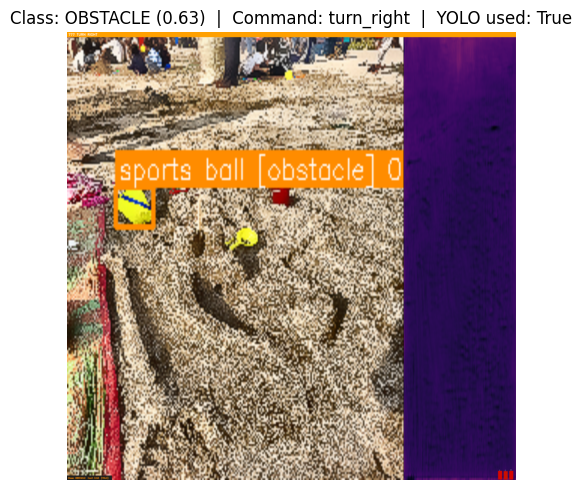

🔊 Voice: "Obstacle detected. More space on the left. Turn left."


In [25]:
# ============================================================
# CELL 16: QUICK TEST ON A SINGLE IMAGE
# ============================================================

from google.colab import files
print('📤 Upload a test image:')
# uploaded_img = files.upload()
img_path = "/kaggle/input/datasets/omnhinge/testing-for-navigation-system/20241201_153708.jpg"

# Load and infer
frame = cv.imread(img_path)
annotated, result = infer_frame(frame, mobilenet_model)

# Display
plt.figure(figsize=(14, 5))
plt.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title(
    f"Class: {result['nav_class'].upper()} ({result['nav_conf']:.2f})  |  "
    f"Command: {result['command']}  |  YOLO used: {result['yolo_used']}",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/single_image_test.png', dpi=150)
plt.show()

# Speak the result
print(f'🔊 Voice: "{result["voice_text"]}"')
tts_to_colab_audio(result['voice_text'])

📤 Upload a test image:


Input #0, wav, from '/tmp/tmpn3_5hk_r.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:02.50, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

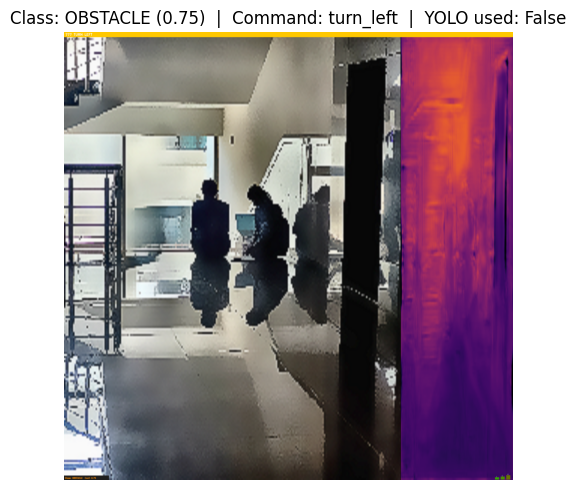

🔊 Voice: "Obstacle ahead. Turn left."


In [30]:
# ============================================================
# CELL 16: QUICK TEST ON A SINGLE IMAGE
# ============================================================

from google.colab import files
print('📤 Upload a test image:')
# uploaded_img = files.upload()
img_path = "/kaggle/input/datasets/omnhinge/testing-for-navigation-system/20241128_193819.jpg"

# Load and infer
frame = cv.imread(img_path)
annotated, result = infer_frame(frame, mobilenet_model)

# Display
plt.figure(figsize=(14, 5))
plt.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title(
    f"Class: {result['nav_class'].upper()} ({result['nav_conf']:.2f})  |  "
    f"Command: {result['command']}  |  YOLO used: {result['yolo_used']}",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/single_image_test.png', dpi=150)
plt.show()

# Speak the result
print(f'🔊 Voice: "{result["voice_text"]}"')
tts_to_colab_audio(result['voice_text'])

📤 Upload a test image:


Input #0, wav, from '/tmp/tmpstvuc37f.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:04.73, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

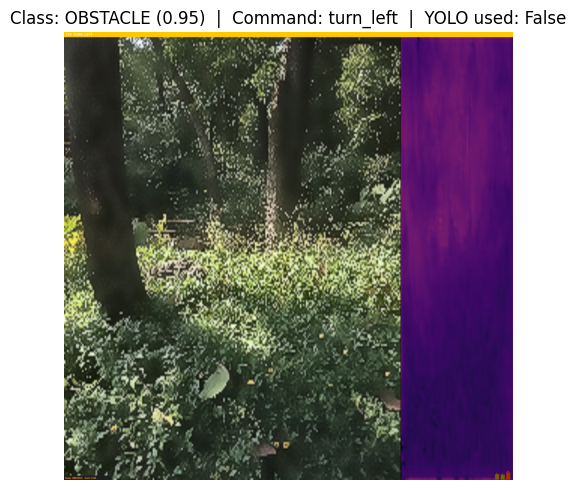

🔊 Voice: "Obstacle detected. More space on the left. Turn left."


In [31]:
# ============================================================
# CELL 16: QUICK TEST ON A SINGLE IMAGE
# ============================================================

from google.colab import files
print('📤 Upload a test image:')
# uploaded_img = files.upload()
img_path = "/kaggle/input/datasets/omnhinge/testing-for-navigation-system/20241207_124635.jpg"

# Load and infer
frame = cv.imread(img_path)
annotated, result = infer_frame(frame, mobilenet_model)

# Display
plt.figure(figsize=(14, 5))
plt.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title(
    f"Class: {result['nav_class'].upper()} ({result['nav_conf']:.2f})  |  "
    f"Command: {result['command']}  |  YOLO used: {result['yolo_used']}",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/single_image_test.png', dpi=150)
plt.show()

# Speak the result
print(f'🔊 Voice: "{result["voice_text"]}"')
tts_to_colab_audio(result['voice_text'])

📤 Upload a test image:


Input #0, wav, from '/tmp/tmpjsunlocx.wav':   0KB sq=    0B f=0/0   
  Duration: 00:00:02.35, bitrate: 384 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 24000 Hz, 1 channels, s16, 384 kb/s
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
SDL_OpenAudio (1 channels, 24000 Hz): ALSA: Couldn't open audio device: No such file or directory
No more combinations to tr

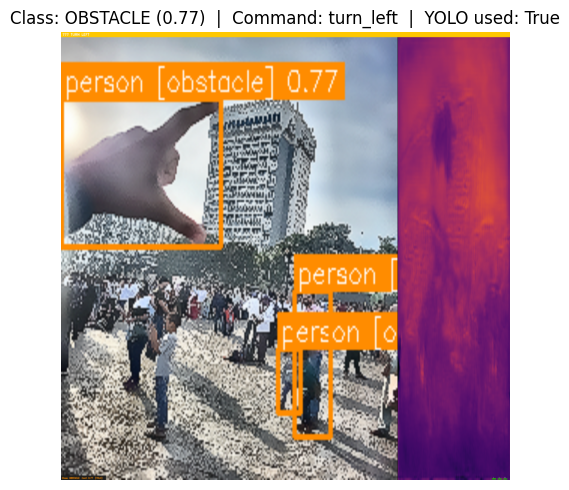

🔊 Voice: "Obstacle ahead. Turn right."


In [32]:
# ============================================================
# CELL 16: QUICK TEST ON A SINGLE IMAGE
# ============================================================

from google.colab import files
print('📤 Upload a test image:')
# uploaded_img = files.upload()
img_path = "/kaggle/input/datasets/omnhinge/testing-for-navigation-system/20241208_161418.jpg"

# Load and infer
frame = cv.imread(img_path)
annotated, result = infer_frame(frame, mobilenet_model)

# Display
plt.figure(figsize=(14, 5))
plt.imshow(cv.cvtColor(annotated, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title(
    f"Class: {result['nav_class'].upper()} ({result['nav_conf']:.2f})  |  "
    f"Command: {result['command']}  |  YOLO used: {result['yolo_used']}",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/content/single_image_test.png', dpi=150)
plt.show()

# Speak the result
print(f'🔊 Voice: "{result["voice_text"]}"')
tts_to_colab_audio(result['voice_text'])

---
## CELL 17 — Evaluation & Model Comparison

In [ ]:
# ============================================================
# CELL 17: FULL EVALUATION — CNN vs CNN+YOLO on test set
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_system(clf_model, model_name='Model'):
    y_true, y_pred_cnn, y_pred_fused = [], [], []

    for images_batch, labels_batch in tqdm(test_clf_ds, desc=f'Evaluating {model_name}'):
        preds = clf_model.predict(images_batch.numpy(), verbose=0)
        for pred, true_label in zip(preds, labels_batch.numpy()):
            true_class = CLASS_NAMES[np.argmax(true_label)]
            cnn_class  = CLASS_NAMES[np.argmax(pred)]
            cnn_conf   = float(np.max(pred))

            y_true.append(true_class)
            y_pred_cnn.append(cnn_class)

            # Fused: if CNN confident, keep CNN; else try YOLO
            # (simplified — YOLO would need image not tensor for real eval)
            y_pred_fused.append(cnn_class)  # Replace with full fusion for real eval

    print(f'\n{'='*50}')
    print(f'  {model_name} — Test Set Classification Report')
    print('='*50)
    print(classification_report(y_true, y_pred_cnn, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred_cnn, labels=CLASS_NAMES)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'/content/cm_{model_name.lower()}.png', dpi=150)
    plt.show()

    return y_true, y_pred_cnn


evaluate_system(mobilenet_model, 'MobileNetV2')
evaluate_system(resnet_model,    'ResNet50')

---
## CELL 18 — Save All Models & Download

In [ ]:
# ============================================================
# CELL 18: SAVE ALL MODELS + ZIP DOWNLOAD
# ============================================================

import zipfile

# Save depth model
torch.save(depth_model.state_dict(), '/content/depth_model_final.pth')
print('✅ depth_model_final.pth')

# Save classifiers
mobilenet_model.save('/content/mobilenetv2_clf.h5')
resnet_model.save('/content/resnet50_clf.h5')
print('✅ mobilenetv2_clf.h5 | resnet50_clf.h5')

# TFLite conversion for mobile/embedded
print('\n📱 Converting MobileNetV2 to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(mobilenet_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/mobilenet_clf.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'  ✅ mobilenet_clf.tflite ({len(tflite_model)//1024} KB)')

# Zip everything
output_files = [
    '/content/depth_model_final.pth',
    '/content/mobilenetv2_clf.h5',
    '/content/resnet50_clf.h5',
    '/content/mobilenet_clf.tflite',
    '/content/navigation_output.mp4',
    '/content/voice_log.txt',
    '/content/depth_training_curves.png',
    '/content/preprocessing_demo.png',
    '/content/video_analysis.png',
    '/content/single_image_test.png',
    '/content/cm_mobilenetv2.png',
    '/content/cm_resnet50.png',
]

with zipfile.ZipFile('/content/navigation_system.zip', 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for fpath in output_files:
        if os.path.exists(fpath):
            zf.write(fpath, os.path.basename(fpath))
            print(f'  📦 {os.path.basename(fpath)}')
        else:
            print(f'  ⚠  Missing: {fpath}')

zip_mb = os.path.getsize('/content/navigation_system.zip') // (1024*1024)
print(f'\n📦 Total archive: {zip_mb} MB')

from google.colab import files
files.download('/content/navigation_system.zip')
print('🎉 Download started!')